In [55]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [56]:
datapath = '/Users/Dung Ho/CS 👻/PythonProjects/Datathon [VinUni]/datathon-2026-round-1/'

In [57]:
customers = pd.read_csv(datapath + 'customers.csv', parse_dates=['signup_date'])
geography = pd.read_csv(datapath + 'geography.csv')
inventory = pd.read_csv(datapath + 'inventory.csv', parse_dates=['snapshot_date'])
order_items = pd.read_csv(datapath + 'order_items.csv')
orders = pd.read_csv(datapath + 'orders.csv', parse_dates=['order_date'])
payments = pd.read_csv(datapath + 'payments.csv')
products = pd.read_csv(datapath + 'products.csv')
promotions = pd.read_csv(datapath + 'promotions.csv', parse_dates=['start_date', 'end_date'])
returns = pd.read_csv(datapath + 'returns.csv', parse_dates=['return_date'])
reviews = pd.read_csv(datapath + 'reviews.csv', parse_dates=['review_date'])
sales = pd.read_csv(datapath + 'sales.csv', parse_dates=['Date'])
sample_submission = pd.read_csv(datapath + 'sample_submission.csv', parse_dates=['Date'])
shipments = pd.read_csv(datapath + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
web_traffic = pd.read_csv(datapath + 'web_traffic.csv', parse_dates=['date'])

**Features engineering**

In [58]:
start_date = sales['Date'].min()
end_date = sample_submission['Date'].max()

In [59]:
cal = pd.DataFrame({'Date': pd.date_range(start_date, end_date)})
cal['train'] = cal['Date'] <= '2022-12-31'
cal

,Date,train
0,2012-07-04,True
1,2012-07-05,True
2,2012-07-06,True
3,2012-07-07,True
4,2012-07-08,True
...,...,...
4376,2024-06-27,False
4377,2024-06-28,False
4378,2024-06-29,False
4379,2024-06-30,False


In [60]:
promo_dates = []
for index, row in promotions.iterrows():
  promo_dates.append(pd.DataFrame({'Date' : pd.date_range(row['start_date'], row['end_date']), 'is_promo' : 1}))
promo_dates = pd.concat(promo_dates).drop_duplicates('Date')
promo_dates = promo_dates.sort_values('Date')

In [61]:
promo_dates

,Date,is_promo
0,2013-01-31,1
1,2013-02-01,1
2,2013-02-02,1
3,2013-02-03,1
4,2013-02-04,1
...,...,...
39,2022-12-27,1
40,2022-12-28,1
41,2022-12-29,1
42,2022-12-30,1


In [62]:
cal = cal.merge(promo_dates, on='Date', how='left')
cal['is_promo'] = cal['is_promo'].fillna(0).astype(int)

In [63]:
cal

,Date,train,is_promo
0,2012-07-04,True,0
1,2012-07-05,True,0
2,2012-07-06,True,0
3,2012-07-07,True,0
4,2012-07-08,True,0
...,...,...,...
4376,2024-06-27,False,0
4377,2024-06-28,False,0
4378,2024-06-29,False,0
4379,2024-06-30,False,0


In [64]:
web_traffic.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


In [65]:
traffic = web_traffic.groupby('date').agg(
    daily_sessions = ('sessions', 'sum'),
    daily_unique_visitors = ('unique_visitors', 'sum'),
    daily_page_views = ('page_views', 'sum'),
    daily_bounce_rate = ('bounce_rate', 'mean'),
    daily_avg_session_duration = ('avg_session_duration_sec', 'mean'),
)
traffic.reset_index(inplace=True)
traffic.rename(columns={'date': 'Date'}, inplace=True)
traffic

,Date,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration
0,2013-01-01,9760,7253,39093,0.00514,102.9
1,2013-01-02,10456,8151,47611,0.00406,120.5
2,2013-01-03,10076,7458,36963,0.00401,263.6
3,2013-01-04,9973,8063,53078,0.00562,151.8
4,2013-01-05,10223,7882,36790,0.00525,168.6
...,...,...,...,...,...,...
3647,2022-12-27,17416,13150,62527,0.00506,252.4
3648,2022-12-28,21071,15979,67456,0.00560,177.3
3649,2022-12-29,20884,14640,82155,0.00522,165.6
3650,2022-12-30,17679,13713,79308,0.00350,183.8


In [66]:
cal = cal.merge(traffic, on='Date', how='left')

In [67]:
traffic_cols = ['daily_sessions', 'daily_unique_visitors', 'daily_page_views', 'daily_bounce_rate', 'daily_avg_session_duration']
cal[traffic_cols] = cal[traffic_cols].fillna(0)

In [68]:
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0


In [69]:
inv = inventory.groupby('snapshot_date').agg(
    total_stock       = ('stock_on_hand', 'sum'),
    avg_sell_through  = ('sell_through_rate', 'mean'),
    avg_fill_rate     = ('fill_rate', 'mean'),
    total_reorder     = ('reorder_flag', 'sum')
).reset_index().rename(columns={'snapshot_date':'Date'})
inv

,Date,total_stock,avg_sell_through,avg_fill_rate,total_reorder
0,2012-07-31,23698,0.243548,0.966075,0
1,2012-08-31,26249,0.288848,0.944919,0
2,2012-09-30,27519,0.243615,0.950001,0
3,2012-10-31,29194,0.220611,0.952631,0
4,2012-11-30,30134,0.195454,0.959855,0
...,...,...,...,...,...
121,2022-08-31,104884,0.144234,0.965220,0
122,2022-09-30,107309,0.118721,0.966984,0
123,2022-10-31,104255,0.114488,0.961776,0
124,2022-11-30,95003,0.104700,0.959929,0


In [70]:
cal = cal.merge(inv, on='Date', how='left')

In [71]:
inv_cols = ['total_stock', 'avg_sell_through', 'avg_fill_rate', 'total_reorder']
cal[inv_cols] = cal[inv_cols].ffill()
cal[inv_cols] = cal[inv_cols].fillna(0)

In [72]:
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,avg_fill_rate,total_reorder
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0


In [73]:
orders_with_payments = orders.merge(payments[['order_id', 'payment_value']], on='order_id', how='left')
orders_with_payments['payment_value'] = orders_with_payments['payment_value'].fillna(0)

In [74]:
daily_orders = orders_with_payments.groupby('order_date').agg(
    total_orders = ('order_id', 'count'),
    total_values = ('payment_value', 'sum')
).reset_index().rename(columns={'order_date' : 'Date'})

In [75]:
cal = cal.merge(daily_orders, on='Date', how='left')
cal[['total_orders', 'total_values']] = cal[['total_orders', 'total_values']].fillna(0)

In [76]:
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,avg_fill_rate,total_reorder,total_orders,total_values
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,162.0,5123547.94
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,97.0,2751773.45
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,93.0,3054029.42
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,73.0,2667930.94
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,88.0,2360851.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00


In [77]:
daily_retuns = returns.groupby('return_date').agg(
    total_returns = ('return_id', 'count'),
    total_refund = ('refund_amount', 'sum')
).reset_index().rename(columns={'return_date' : 'Date'})

In [78]:
cal = cal.merge(daily_retuns, on='Date', how='left')
cal[['total_returns', 'total_refund']] = cal[['total_returns', 'total_refund']].fillna(0)

In [79]:
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,avg_fill_rate,total_reorder,total_orders,total_values,total_returns,total_refund
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,162.0,5123547.94,0.0,0.0
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,97.0,2751773.45,0.0,0.0
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,93.0,3054029.42,0.0,0.0
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,73.0,2667930.94,0.0,0.0
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,88.0,2360851.90,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0


In [80]:
daily_reviews = reviews.groupby('review_date').agg(
    total_reviews = ('review_id', 'count'),
    avg_rating = ('rating', 'mean'),
).reset_index().rename(columns={'review_date' : 'Date'})

In [81]:
cal = cal.merge(daily_reviews, on='Date', how='left')
cal[['total_reviews', 'avg_rating']] = cal[['total_reviews', 'avg_rating']].fillna(0)

In [82]:
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,avg_fill_rate,total_reorder,total_orders,total_values,total_returns,total_refund,total_reviews,avg_rating
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,162.0,5123547.94,0.0,0.0,0.0,0.0
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,97.0,2751773.45,0.0,0.0,0.0,0.0
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,93.0,3054029.42,0.0,0.0,0.0,0.0
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,73.0,2667930.94,0.0,0.0,0.0,0.0
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,88.0,2360851.90,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0


In [83]:
cols_lag = [
    'is_promo', 'daily_sessions', 'daily_unique_visitors', 'daily_page_views',
    'daily_bounce_rate', 'daily_avg_session_duration','total_stock',
    'avg_sell_through', 'avg_fill_rate', 'total_reorder',
    'total_orders', 'total_values', 'total_returns', 'total_refund',
    'total_reviews', 'avg_rating'
]

for col in cols_lag:
  cal[col + '_prev'] = cal[col].shift(1)
cal[cal['Date'] == start_date] = cal[cal['Date'] == start_date].fillna(0)
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,...,total_stock_prev,avg_sell_through_prev,avg_fill_rate_prev,total_reorder_prev,total_orders_prev,total_values_prev,total_returns_prev,total_refund_prev,total_reviews_prev,avg_rating_prev
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,162.0,5123547.94,0.0,0.0,0.0,0.0
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,97.0,2751773.45,0.0,0.0,0.0,0.0
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,93.0,3054029.42,0.0,0.0,0.0,0.0
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,73.0,2667930.94,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0


In [84]:
df_train = cal[cal['train']].copy()
df_train = df_train.merge(sales, on='Date', how='left')

In [85]:
target = ['Revenue', 'COGS']
lags = [1, 7, 14, 30]
for col in target:
    for lag in lags:
      df_train[f"{col}_lag{lag}"] = df_train[col].shift(lag)
    df_train[f"{col}_rolling_mean_7"] = df_train[col].shift(1).rolling(window=7).mean()
    df_train[f"{col}_rolling_std_7"] = df_train[col].shift(1).rolling(window=7).std()
    df_train[f"{col}_rolling_mean_14"] = df_train[col].shift(1).rolling(window=14).mean()
    df_train[f"{col}_rolling_std_14"] = df_train[col].shift(1).rolling(window=14).std()
    df_train[f"{col}_rolling_mean_30"] = df_train[col].shift(1).rolling(window=30).mean()
    df_train[f"{col}_rolling_std_30"] =  df_train[col].shift(1).rolling(window=30).std()
df_train

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,...,COGS_lag1,COGS_lag7,COGS_lag14,COGS_lag30,COGS_rolling_mean_7,COGS_rolling_std_7,COGS_rolling_mean_14,COGS_rolling_std_14,COGS_rolling_mean_30,COGS_rolling_std_30
0,2012-07-04,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,3982991.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,2150580.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,2517632.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,2108246.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,True,1,17416.0,13150.0,62527.0,0.00506,252.4,95003.0,0.104700,...,2160963.69,2053084.16,1687562.98,3283279.48,1.693680e+06,359294.482574,1.727411e+06,354057.733675,1.626506e+06,593849.473192
3829,2022-12-28,True,1,21071.0,15979.0,67456.0,0.00560,177.3,95003.0,0.104700,...,2184872.24,1806884.57,1688191.22,2152332.40,1.712507e+06,383877.696538,1.762933e+06,374130.512962,1.589892e+06,517077.859614
3830,2022-12-29,True,1,20884.0,14640.0,82155.0,0.00522,165.6,95003.0,0.104700,...,3513621.00,1773829.08,1554407.68,2694391.19,1.956326e+06,785614.682956,1.893320e+06,597492.641562,1.635268e+06,618015.161025
3831,2022-12-30,True,1,17679.0,13713.0,79308.0,0.00350,183.8,95003.0,0.104700,...,3170787.10,1499234.75,1521540.05,1346354.39,2.155892e+06,900552.447578,2.008776e+06,677745.461679,1.651148e+06,651387.139020


In [86]:
df_train['year'] = df_train['Date'].dt.year
df_train['month'] = df_train['Date'].dt.month
df_train['day'] = df_train['Date'].dt.day
df_train['day_of_week'] = df_train['Date'].dt.dayofweek
df_train['day_of_year'] = df_train['Date'].dt.dayofyear
df_train['quarter'] = df_train['Date'].dt.quarter
df_train['week_of_year'] = df_train['Date'].dt.isocalendar().week.astype(int)
df_train['is_weekend'] = (df_train['day_of_week'] >= 5).astype(int)
df_train['is_month_start'] = df_train['Date'].dt.is_month_start.astype(int)
df_train['is_month_end'] = df_train['Date'].dt.is_month_end.astype(int)
df_train['tet_season'] = df_train['month'].isin([1, 2]).astype(int)
df_train['sale_season'] = df_train['month'].isin([11, 12]).astype(int)
df_train['mid_year'] = df_train['month'].isin([6, 7]).astype(int)
df_train['month_sin'] = np.sin(2 * np.pi * df_train['month'] / 12)
df_train['month_cos'] = np.cos(2 * np.pi * df_train['month'] / 12)
df_train['dow_sin'] = np.sin(2 * np.pi * df_train['day_of_week'] / 7)
df_train['dow_cos'] = np.cos(2 * np.pi * df_train['day_of_week'] / 7)
df_train['is_double_day'] = (df_train['day'] == df_train['month']).astype(int)

In [87]:
df_train = df_train.dropna(subset=['Revenue', 'COGS']).reset_index(drop=True)
df_train

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,...,is_month_start,is_month_end,tet_season,sale_season,mid_year,month_sin,month_cos,dow_sin,dow_cos,is_double_day
0,2012-07-04,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,0.974928,-0.222521,0
1,2012-07-05,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,0.433884,-0.900969,0
2,2012-07-06,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.433884,-0.900969,0
3,2012-07-07,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.974928,-0.222521,1
4,2012-07-08,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.781831,0.623490,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,True,1,17416.0,13150.0,62527.0,0.00506,252.4,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,0.781831,0.623490,0
3829,2022-12-28,True,1,21071.0,15979.0,67456.0,0.00560,177.3,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,0.974928,-0.222521,0
3830,2022-12-29,True,1,20884.0,14640.0,82155.0,0.00522,165.6,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,0.433884,-0.900969,0
3831,2022-12-30,True,1,17679.0,13713.0,79308.0,0.00350,183.8,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,-0.433884,-0.900969,0


In [88]:
feature_cols = [col for col in df_train.columns if col not in ['Date', 'Revenue', 'COGS', 'train']]
feature_cols = df_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
df_train[feature_cols] = df_train[feature_cols].fillna(0)

In [89]:
df_train

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,...,is_month_start,is_month_end,tet_season,sale_season,mid_year,month_sin,month_cos,dow_sin,dow_cos,is_double_day
0,2012-07-04,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,0.974928,-0.222521,0
1,2012-07-05,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,0.433884,-0.900969,0
2,2012-07-06,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.433884,-0.900969,0
3,2012-07-07,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.974928,-0.222521,1
4,2012-07-08,True,0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.781831,0.623490,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,True,1,17416.0,13150.0,62527.0,0.00506,252.4,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,0.781831,0.623490,0
3829,2022-12-28,True,1,21071.0,15979.0,67456.0,0.00560,177.3,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,0.974928,-0.222521,0
3830,2022-12-29,True,1,20884.0,14640.0,82155.0,0.00522,165.6,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,0.433884,-0.900969,0
3831,2022-12-30,True,1,17679.0,13713.0,79308.0,0.00350,183.8,95003.0,0.104700,...,0,0,0,1,0,-2.449294e-16,1.000000,-0.433884,-0.900969,0


In [90]:
X = df_train[feature_cols]
Y_revenue = df_train['Revenue']
Y_cogs = df_train['COGS']
is_train = df_train['Date'] <= '2020-12-31'
is_validation = df_train['Date'] > '2020-12-31'
X_train, X_validation = X[is_train], X[is_validation]
Y_revenue_train, Y_revenue_validation = Y_revenue[is_train], Y_revenue[is_validation]
Y_cogs_train, Y_cogs_validation = Y_cogs[is_train], Y_cogs[is_validation]

In [91]:
def train_lgbm(X_tr, y_tr, X_val, y_val, target_name='Revenue'):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'num_leaves': 63,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'seed': 42,
        'verbosity': -1,
        'force_col_wise': True
    }
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dtrain, dval],
        valid_names=['train','valid'],
        num_boost_round=2000,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
    )
    pred = model.predict(X_val)
    mae  = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2   = r2_score(y_val, pred)
    print(f"\n{target_name} - MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R²: {r2:.4f}")
    return model


In [92]:
model_revenue = train_lgbm(X_train, Y_revenue_train, X_validation, Y_revenue_validation, target_name='Revenue')

Training until validation scores don't improve for 100 rounds
[100]	train's l1: 59064.5	valid's l1: 89386.5
[200]	train's l1: 31142.7	valid's l1: 83493.4
[300]	train's l1: 20376.3	valid's l1: 82545.9
[400]	train's l1: 14597.8	valid's l1: 82478.3
[500]	train's l1: 11292.5	valid's l1: 82280
Early stopping, best iteration is:
[420]	train's l1: 13878.5	valid's l1: 81934.8

Revenue - MAE: 81,934.79 | RMSE: 120,892.50 | R²: 0.9947


In [93]:
model_cogs = train_lgbm(X_train, Y_cogs_train, X_validation, Y_cogs_validation, target_name='COGS')

Training until validation scores don't improve for 100 rounds
[100]	train's l1: 77808.7	valid's l1: 185242
Early stopping, best iteration is:
[68]	train's l1: 110566	valid's l1: 181941

COGS - MAE: 181,941.34 | RMSE: 283,309.61 | R²: 0.9618


In [94]:
cal

,Date,train,is_promo,daily_sessions,daily_unique_visitors,daily_page_views,daily_bounce_rate,daily_avg_session_duration,total_stock,avg_sell_through,...,total_stock_prev,avg_sell_through_prev,avg_fill_rate_prev,total_reorder_prev,total_orders_prev,total_values_prev,total_returns_prev,total_refund_prev,total_reviews_prev,avg_rating_prev
0,2012-07-04,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,2012-07-05,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,162.0,5123547.94,0.0,0.0,0.0,0.0
2,2012-07-06,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,97.0,2751773.45,0.0,0.0,0.0,0.0
3,2012-07-07,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,93.0,3054029.42,0.0,0.0,0.0,0.0
4,2012-07-08,True,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,73.0,2667930.94,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4377,2024-06-28,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4378,2024-06-29,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4379,2024-06-30,False,0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,...,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0


In [95]:
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
df_future = pd.DataFrame({'Date': future_dates, 'Revenue': np.nan, 'COGS': np.nan})
df_future = pd.concat([sales, df_future]).reset_index(drop=True)
df_future = df_future.sort_values('Date').reset_index(drop=True)
df_future

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
4376,2024-06-27,NaN,NaN
4377,2024-06-28,NaN,NaN
4378,2024-06-29,NaN,NaN
4379,2024-06-30,NaN,NaN


In [96]:
cal.info()

<class 'pandas.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             4381 non-null   datetime64[us]
 1   train                            4381 non-null   bool          
 2   is_promo                         4381 non-null   int64         
 3   daily_sessions                   4381 non-null   float64       
 4   daily_unique_visitors            4381 non-null   float64       
 5   daily_page_views                 4381 non-null   float64       
 6   daily_bounce_rate                4381 non-null   float64       
 7   daily_avg_session_duration       4381 non-null   float64       
 8   total_stock                      4381 non-null   float64       
 9   avg_sell_through                 4381 non-null   float64       
 10  avg_fill_rate                    4381 non-null   float64       
 11  to

In [97]:
cols_to_select = ['Date'] + [col+'_prev' for col in cols_lag]
cal_to_select = cal[cols_to_select].copy()
df_future = df_future.merge(cal_to_select, on='Date', how='left')
df_future

,Date,Revenue,COGS,is_promo_prev,daily_sessions_prev,daily_unique_visitors_prev,daily_page_views_prev,daily_bounce_rate_prev,daily_avg_session_duration_prev,total_stock_prev,avg_sell_through_prev,avg_fill_rate_prev,total_reorder_prev,total_orders_prev,total_values_prev,total_returns_prev,total_refund_prev,total_reviews_prev,avg_rating_prev
0,2012-07-04,5123547.94,3982991.19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,2012-07-05,2751773.45,2150580.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,162.0,5123547.94,0.0,0.0,0.0,0.0
2,2012-07-06,3054029.42,2517632.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,97.0,2751773.45,0.0,0.0,0.0,0.0
3,2012-07-07,2667930.94,2108246.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,93.0,3054029.42,0.0,0.0,0.0,0.0
4,2012-07-08,2360851.90,1808622.79,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,73.0,2667930.94,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4377,2024-06-28,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4378,2024-06-29,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0
4379,2024-06-30,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,0.118345,0.961244,0.0,0.0,0.00,0.0,0.0,0.0,0.0


In [98]:
df_future['year'] = df_future['Date'].dt.year
df_future['month'] = df_future['Date'].dt.month
df_future['day'] = df_future['Date'].dt.day
df_future['day_of_week'] = df_future['Date'].dt.dayofweek
df_future['day_of_year'] = df_future['Date'].dt.dayofyear
df_future['quarter'] = df_future['Date'].dt.quarter
df_future['week_of_year'] = df_future['Date'].dt.isocalendar().week.astype(int)
df_future['is_weekend'] = (df_future['day_of_week'] >= 5).astype(int)
df_future['is_month_start'] = df_future['Date'].dt.is_month_start.astype(int)
df_future['is_month_end'] = df_future['Date'].dt.is_month_end.astype(int)
df_future['tet_season'] = df_future['month'].isin([1, 2]).astype(int)
df_future['sale_season'] = df_future['month'].isin([11, 12]).astype(int)
df_future['mid_year'] = df_future['month'].isin([6, 7]).astype(int)
df_future['month_sin'] = np.sin(2 * np.pi * df_future['month'] / 12)
df_future['month_cos'] = np.cos(2 * np.pi * df_future['month'] / 12)
df_future['dow_sin'] = np.sin(2 * np.pi * df_future['day_of_week'] / 7)
df_future['dow_cos'] = np.cos(2 * np.pi * df_future['day_of_week'] / 7)
df_future['is_double_day'] = (df_future['day'] == df_future['month']).astype(int)

In [99]:
df_future

,Date,Revenue,COGS,is_promo_prev,daily_sessions_prev,daily_unique_visitors_prev,daily_page_views_prev,daily_bounce_rate_prev,daily_avg_session_duration_prev,total_stock_prev,...,is_month_start,is_month_end,tet_season,sale_season,mid_year,month_sin,month_cos,dow_sin,dow_cos,is_double_day
0,2012-07-04,5123547.94,3982991.19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,-5.000000e-01,-0.866025,0.974928,-0.222521,0
1,2012-07-05,2751773.45,2150580.23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,-5.000000e-01,-0.866025,0.433884,-0.900969,0
2,2012-07-06,3054029.42,2517632.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.433884,-0.900969,0
3,2012-07-07,2667930.94,2108246.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.974928,-0.222521,1
4,2012-07-08,2360851.90,1808622.79,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,-5.000000e-01,-0.866025,-0.781831,0.623490,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,...,0,0,0,0,1,1.224647e-16,-1.000000,0.433884,-0.900969,0
4377,2024-06-28,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,...,0,0,0,0,1,1.224647e-16,-1.000000,-0.433884,-0.900969,0
4378,2024-06-29,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,...,0,0,0,0,1,1.224647e-16,-1.000000,-0.974928,-0.222521,0
4379,2024-06-30,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,104235.0,...,0,1,0,0,1,1.224647e-16,-1.000000,-0.781831,0.623490,0


In [100]:
for col in feature_cols:
  if col not in df_future.columns:
    df_future[col] = 0.0

In [101]:
df_future.info()

<class 'pandas.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 73 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             4381 non-null   datetime64[us]
 1   Revenue                          3833 non-null   float64       
 2   COGS                             3833 non-null   float64       
 3   is_promo_prev                    4381 non-null   float64       
 4   daily_sessions_prev              4381 non-null   float64       
 5   daily_unique_visitors_prev       4381 non-null   float64       
 6   daily_page_views_prev            4381 non-null   float64       
 7   daily_bounce_rate_prev           4381 non-null   float64       
 8   daily_avg_session_duration_prev  4381 non-null   float64       
 9   total_stock_prev                 4381 non-null   float64       
 10  avg_sell_through_prev            4381 non-null   float64       
 11  av

In [102]:
start_idx = df_future[df_future['Date'] == pd.to_datetime('2023-01-01')].index[0]
for i in range(start_idx, len(df_future)):
  past = df_future.loc[:i].copy()
  for target in ['Revenue', 'COGS']:
    target_column = past[target]
    df_future.loc[i, f"{target}_lag1"] = target_column.shift(1).iloc[i]
    df_future.loc[i, f"{target}_lag7"] = target_column.shift(7).iloc[i]
    df_future.loc[i, f"{target}_lag14"] = target_column.shift(14).iloc[i]
    df_future.loc[i, f"{target}_lag30"] = target_column.shift(30).iloc[i]
    df_future.loc[i, f"{target}_rolling_mean_7"] = target_column.shift(1).rolling(window=7).mean().iloc[i]
    df_future.loc[i, f"{target}_rolling_std_7"] = target_column.shift(1).rolling(window=7).std().iloc[i]
    df_future.loc[i, f"{target}_rolling_mean_14"] = target_column.shift(1).rolling(window=14).mean().iloc[i]
    df_future.loc[i, f"{target}_rolling_std_14"] = target_column.shift(1).rolling(window=14).std().iloc[i]
    df_future.loc[i, f"{target}_rolling_mean_30"] = target_column.shift(1).rolling(window=30).mean().iloc[i]
    df_future.loc[i, f"{target}_rolling_std_30"] = target_column.shift(1).rolling(window=30).std().iloc[i]
  df_future[feature_cols] = df_future[feature_cols].fillna(0)
  curr = pd.DataFrame([df_future.loc[i, feature_cols].values], columns=feature_cols)
  df_future.loc[i, 'Revenue'] = model_revenue.predict(curr)[0]
  df_future.loc[i, 'COGS'] = model_cogs.predict(curr)[0]

In [103]:
submission = df_future[df_future['Date'] >= pd.to_datetime('2023-01-01')][['Date', 'Revenue', 'COGS']].copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

In [104]:
submission.to_csv('submission.csv', index=False)

In [105]:
import shap
import matplotlib.pyplot as plt
X_shap = X_validation.sample(n=min(500, len(X_validation)), random_state=42)

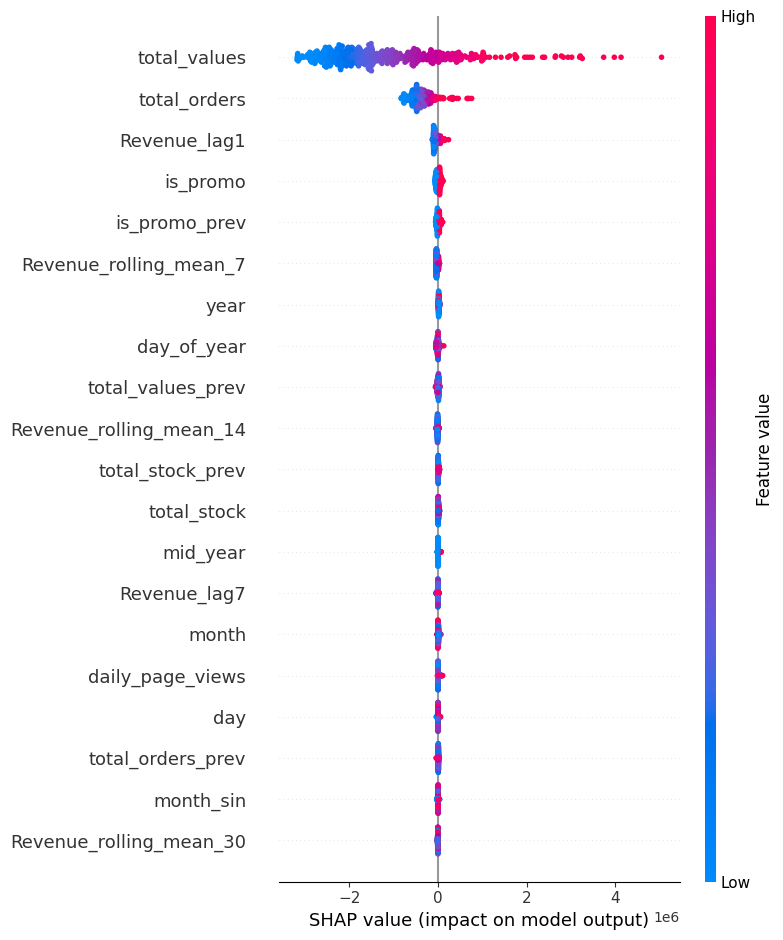

In [106]:
explainer_rev = shap.TreeExplainer(model_revenue)
shap_rev = explainer_rev.shap_values(X_shap)

shap.summary_plot(shap_rev, X_shap, max_display=None, show=True)

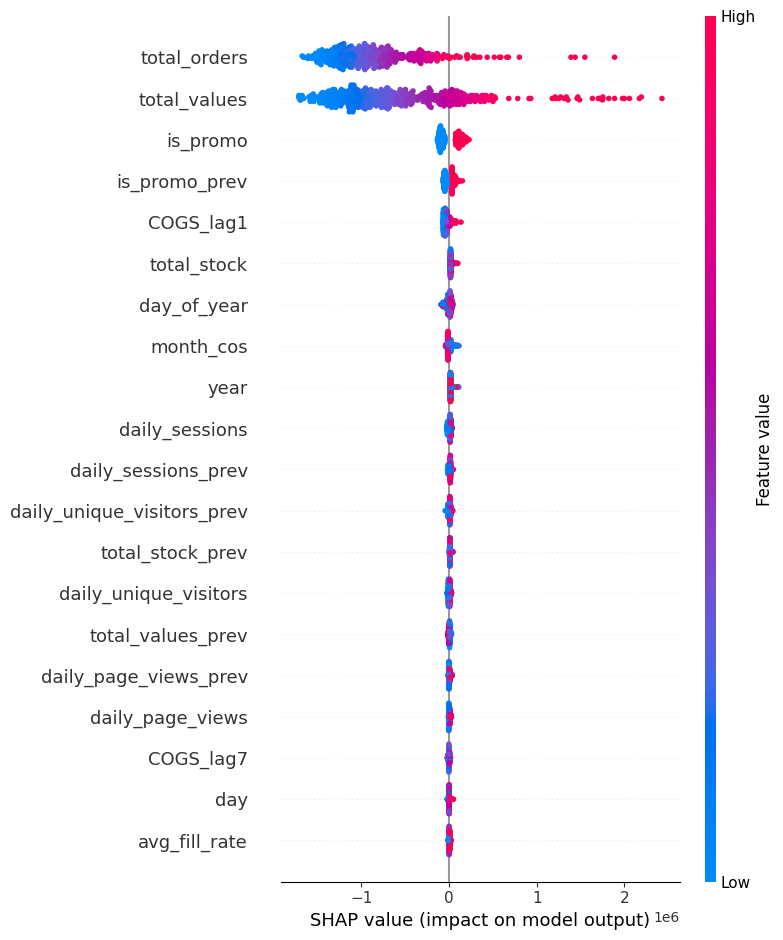

In [107]:
explainer_cogs = shap.TreeExplainer(model_cogs)
shap_cogs = explainer_cogs.shap_values(X_shap)

shap.summary_plot(shap_cogs, X_shap, max_display=None, show=True)